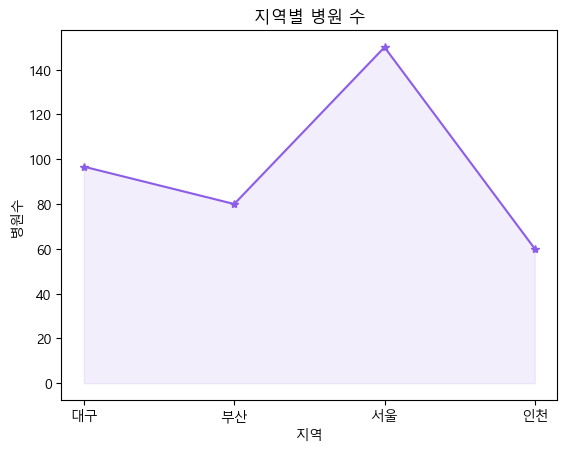

In [1]:
import pandas as pd
# matplotlib : 메트플롯 반드시 import 한다
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline

# 데이터 생성
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [10000000, 3000000, 2000000]
})
df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 전처리를 위해 merge
# outer 로 병합하면 df1과 df2가 합집합된다
merged = pd.merge(df1, df2, on="지역", how= "outer")
# merged

# 결측치 처리
# 결측치는 병원수와 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

# -------------------------------------------

# 가로 막대 그래프 만들기 : plt.bar
# x축 : 지역 / y축 : 병원수

# 반드시 한글 깨짐현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺾은선 그래프
bars= plt.plot(merged['지역'], merged['병원수'], color='#8c5ee8', marker='*')
# x축 기준으로 선 아래를 채움 : fill_between(x, y)
# 투명도 : alpha = 0.3 / 0.1 : 거의 투명, 0.3 적당, 1~ 이주 진함
plt.fill_between(merged['지역'], merged['병원수'], alpha=0.1, color='#8c5ee8')

# 곡선 그래프
# x축을 숫자로 변환
x = np.arange(len(merged['지역']))
y = merged['병원수']

smooth01 = np.linspace(x.min(), x.max(), 300)  # 300 : 곡선의 정도
smooth02 = make_interp_spline(x, y)(smooth01)

# bars= plt.plot(smooth01, smooth02, color='#8c5ee8')

plt.title('지역별 병원 수')
plt.xlabel('지역')
plt.ylabel('병원수')

plt.show()

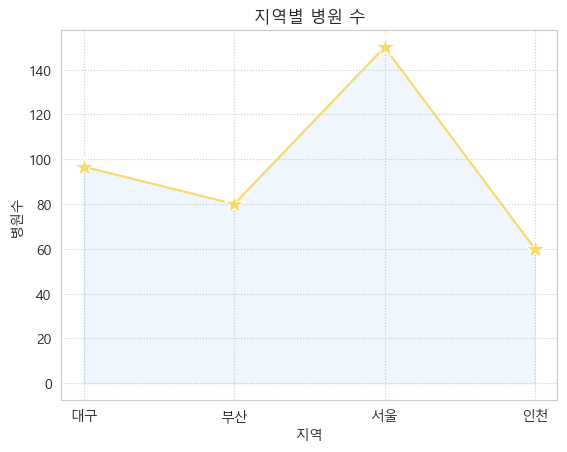

In [9]:
import pandas as pd
# matplotlib : 메트플롯 반드시 import 한다
import matplotlib.pyplot as plt
# 숫자 계산을 쉽게 하기 위한 라이브러리
import numpy as np
# 데이터 사이를 부드럽게 연결해주는 함수
from scipy.interpolate import make_interp_spline
# seaborn : matplotlib 기간의 차트 예쁘게 꾸미는 도구
import seaborn as sns

# 데이터 생성
df1 = pd.DataFrame({
    "지역": ["서울", "부산", "대구"],
    "총인구": [10000000, 3000000, 2000000]
})
df2 = pd.DataFrame({
    "지역": ["서울", "부산", "인천"],
    "병원수": [150, 80, 60]
})

# 데이터 전처리를 위해 merge
# outer 로 병합하면 df1과 df2가 합집합된다
merged = pd.merge(df1, df2, on="지역", how= "outer")
# merged

# 결측치 처리
# 결측치는 병원수와 총인구의 평균으로 정의한다
merged['총인구'] = merged['총인구'].fillna(merged['총인구'].mean())
merged['병원수'] = merged['병원수'].fillna(merged['병원수'].mean())
merged

# -------------------------------------------

# 가로 막대 그래프 만들기 : plt.bar
# x축 : 지역 / y축 : 병원수

# seaborn 스타일 지정
sns.set_style('whitegrid')  # 배경 스타일 - dark : 그리도 없이 어두운 배경
sns.set_palette('deep')  # 막대 색상 스타일 - deep : 진하게

# 반드시 한글 깨짐현상 코드를 삽입한다.
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 꺾은선 그래프
# bars= plt.plot(merged['지역'], merged['병원수'], color='#8c5ee8', marker='*')
ax = sns.lineplot(x='지역', y='병원수', data=merged, marker='*', markersize=15, color='#f8da6c')
# x축 기준으로 선 아래를 채움 : fill_between(x, y)
# 투명도 : alpha = 0.3 / 0.1 : 거의 투명, 0.3 적당, 1~ 이주 진함
plt.fill_between(merged['지역'], merged['병원수'], alpha=0.1, color='#6cadf8')

# 곡선 그래프
# x축을 숫자로 변환
x = np.arange(len(merged['지역']))
y = merged['병원수']

smooth01 = np.linspace(x.min(), x.max(), 300)  # 300 : 곡선의 정도
smooth02 = make_interp_spline(x, y)(smooth01)

# bars= plt.plot(smooth01, smooth02, color='#8c5ee8')

plt.grid(linestyle=':')

plt.title('지역별 병원 수')
plt.xlabel('지역')
plt.ylabel('병원수')

plt.show()